# 09 - MNIST with a Feedforward Network

**Section:** FNNs | **Prereqs:** `ANNs/CodeChallenge.ipynb` | **Next:** `FNNs/BinaryMNIST.ipynb`

First real dataset, and the template every later notebook follows.

**What is new here**
- **Flattening.** A 28x28 image becomes a 784-vector (`view(-1, 784)`). A fully
  connected net has no idea the pixels form a grid - it treats pixel 0 and
  pixel 783 as unrelated features. Fixing that is what CNNs are for.
- **`DataLoader`.** Batching, shuffling and iteration handled for you. Shuffle
  the training set (so batch composition changes each epoch), never the test set.
- **A held-out test set.** Two accuracy curves from now on. Train accuracy alone
  tells you nothing about generalisation.
- **`.train()` / `.eval()` and `torch.no_grad()`** around evaluation.
- **`log_softmax` + `NLLLoss`.** Mathematically identical to `CrossEntropyLoss`
  on raw logits - one of the two pairings, never both.

**The pairing rule** (worth memorising)

| Model's last op | Loss to use |
|---|---|
| raw logits | `CrossEntropyLoss` |
| `log_softmax` | `NLLLoss` |
| `Softmax` | neither - this is the classic bug |

In [4]:
# torchvision supplies the dataset; torch.utils.data supplies batching.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset,DataLoader

from torchvision.transforms import ToTensor
from torchvision.datasets import MNIST

In [5]:
# MNIST: 60000 training and 10000 test images, 28x28 grayscale, digits 0-9.
# torchvision downloads it once into ./data and caches it after that.
# train=True / train=False select the two official splits.
data = MNIST(
    root='./data',        # Directory to store the dataset
    train=True,           # Load the training set
    download=True,
    transform = ToTensor()
)

test_data =  MNIST(
    root='./data',        # Directory to store the dataset
    train=False,           # Load the training set
    download=True,
    transform = ToTensor()
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 41.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.10MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.83MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.3MB/s]


In [6]:
# The dataset object reports its size, root and transforms.
data

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: ToTensor()

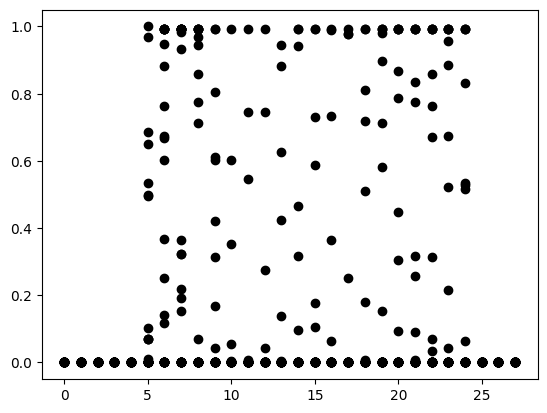

In [ ]:
# data[0][0] is the first image as a (1,28,28) tensor - plotted as 28 lines
# rather than a picture, since plt.plot draws columns, not images.
plt.plot(data[0][0].detach().reshape(28,28), "ko");


In [ ]:
# Flatten each image to a 784-vector: (60000,28,28) -> (60000,784).
# Note .data returns the RAW uint8 pixels (0-255) and bypasses the ToTensor
# transform above, so these are not scaled to [0,1] - see
# Metaparameters/Normalization.ipynb for why that matters.
# .clone().detach() is the correct way to copy an existing tensor -
# torch.tensor(existing_tensor) does the same thing but warns.
train_data = data.data.view(-1, 784)
train_label = data.targets.clone().detach().to('cuda')


test_label = test_data.targets.clone().detach().to('cuda')
test_data = test_data.data.view(-1,784)


/tmp/ipython-input-5-240061661.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_label = torch.tensor(data.targets,device='cuda')
/tmp/ipython-input-5-240061661.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_label = torch.tensor(test_data.targets,device='cuda')


In [ ]:
# Ten classes, 0-9, as expected.
test_label.unique()

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], device='cuda:0')

In [ ]:
# (60000,784) images and (60000,) labels - one integer class per image.
train_data.shape , train_label.shape

(torch.Size([60000, 784]), torch.Size([60000]))

tensor(0, device='cuda:0')


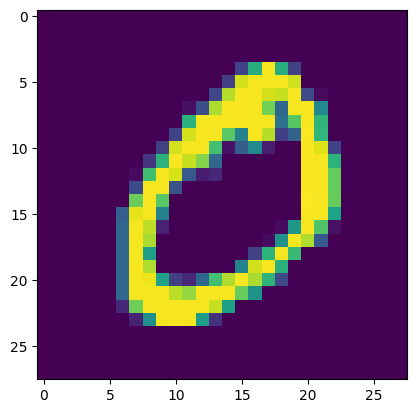

In [ ]:
# Reshaping a row back to 28x28 proves the flattening was lossless: the layout
# information is still there, the network just is not told about it.
plt.imshow(np.reshape(train_data[1],(28,28)));
print(train_label[1])

In [ ]:
# Wrap tensors in a TensorDataset (pairs x with y) and hand it to a DataLoader.
#   batch_size=32   - how many samples per gradient update,
#   shuffle=True    - reshuffle every epoch, so batches differ (train only),
#   drop_last=True  - discard the final short batch to keep shapes uniform.
# The test loader uses one batch the size of the whole test set: no gradients
# are computed there, so there is no reason to chunk it.
train_data = torch.tensor(train_data,dtype=torch.float,device='cuda')
test_data = torch.tensor(test_data,dtype=torch.float,device="cuda")

train_data = TensorDataset(train_data,train_label)
test_data = TensorDataset(test_data,test_label)

bs = 32
data_loader = DataLoader(train_data, batch_size=bs, drop_last=True, shuffle=True)
test_loader = DataLoader(test_data, batch_size=test_data.tensors[0].shape[0])



/tmp/ipython-input-9-2963994144.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_data = torch.tensor(train_data,dtype=torch.float,device='cuda')
/tmp/ipython-input-9-2963994144.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_data = torch.tensor(test_data,dtype=torch.float,device="cuda")


In [ ]:
# 10000 test images x 784 pixels.
test_data.tensors[0].shape

torch.Size([10000, 784])

In [ ]:
# Every batch is (32,784) images and (32,) labels. Iterating the loader is what
# 'one epoch' means.
for x,y in data_loader:
  print(x.shape,y.shape)

torch.Size([32, 784]) torch.Size([32])
torch.Size([32, 784]) torch.Size([32])
torch.Size([32, 784]) torch.Size([32])
torch.Size([32, 784]) torch.Size([32])
torch.Size([32, 784]) torch.Size([32])
torch.Size([32, 784]) torch.Size([32])
torch.Size([32, 784]) torch.Size([32])
torch.Size([32, 784]) torch.Size([32])
torch.Size([32, 784]) torch.Size([32])
torch.Size([32, 784]) torch.Size([32])
torch.Size([32, 784]) torch.Size([32])
torch.Size([32, 784]) torch.Size([32])
torch.Size([32, 784]) torch.Size([32])
torch.Size([32, 784]) torch.Size([32])
torch.Size([32, 784]) torch.Size([32])
torch.Size([32, 784]) torch.Size([32])
torch.Size([32, 784]) torch.Size([32])
torch.Size([32, 784]) torch.Size([32])
torch.Size([32, 784]) torch.Size([32])
torch.Size([32, 784]) torch.Size([32])
torch.Size([32, 784]) torch.Size([32])
torch.Size([32, 784]) torch.Size([32])
torch.Size([32, 784]) torch.Size([32])
torch.Size([32, 784]) torch.Size([32])
torch.Size([32, 784]) torch.Size([32])
torch.Size([32, 784]) tor

In [ ]:
# 784 -> 128 -> 64 -> 32 -> 10, ReLU between layers.
# The output is log_softmax, i.e. LOG-PROBABILITIES over the 10 digits, which
# pairs with NLLLoss below. dim=1 normalises across classes, per sample.
class model(nn.Module):
  def __init__(self):
    super().__init__()

    self.input_layer = nn.Linear(784, 128)

    self.fc1 = nn.Linear(128,64)

    self.fc2 = nn.Linear(64,32)

    self.output_layer = nn.Linear(32,10)


  def forward(self,x):

    x = F.relu(self.input_layer(x))

    x = F.relu(self.fc1(x))

    x = F.relu(self.fc2(x))

    return torch.log_softmax(self.output_layer(x), dim=1)

In [ ]:
# The reusable training function used from here on. Five things it does that
# the toy loops in ANNs/ did not:
#   1. builds a FRESH model inside the function, so repeated calls are independent,
#   2. loops over mini-batches from the DataLoader instead of the whole dataset,
#   3. calls .train() / .eval() to switch dropout and batch-norm modes,
#   4. wraps evaluation in torch.no_grad() - no graph, less memory, faster,
#   5. records train AND test accuracy each epoch, which is how you SEE overfitting.
# Adam is used instead of plain SGD: it adapts a per-parameter learning rate and
# needs far less tuning (Metaparameters/RMSprop_and_Adam.ipynb explains it).
def train_model():

  classifier = model().to('cuda')

  epochs = 100
  lr = 0.0001

  lossFunc = nn.NLLLoss()
  optimizer = torch.optim.Adam(classifier.parameters(), lr=lr)

  test_acc = []
  train_acc = []
  losses = torch.zeros(epochs)


  for i in range(epochs):

    classifier.train()
    batch_acc = []
    batch_loss = []

    for x,y in data_loader:

      yhat = classifier(x)

      loss = lossFunc(yhat,y)
      batch_loss.append(loss.item())


      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      batch_acc.append(100 * torch.mean( (torch.argmax(yhat,dim = 1) == y).float()).cpu() )

    train_acc.append(np.mean(batch_acc))
    losses[i] = np.mean(batch_loss)

    if i % 10 == 0 or i == epochs-1:
      print(f"Epoch {i} : Loss = {losses[i].item()}")

    classifier.eval()
    with torch.no_grad():
      X,Y = next(iter(test_loader))
      Preds = torch.argmax(classifier(X), dim = 1)
      test_acc.append( 100 * torch.mean( (Preds == Y).float()) )


  return losses, train_acc, test_acc, classifier


In [ ]:
# Train once. On a GPU this is a minute or two; on CPU, much longer.
losses, train_acc, test_acc, classifier = train_model()

Epoch 0 : Loss = 0.38942140340805054
Epoch 10 : Loss = 0.01618594489991665
Epoch 20 : Loss = 0.007833203300833702
Epoch 30 : Loss = 0.00514729181304574
Epoch 40 : Loss = 0.004936350509524345
Epoch 50 : Loss = 0.004658473189920187
Epoch 60 : Loss = 0.0030510707292705774
Epoch 70 : Loss = 0.0035510226152837276
Epoch 80 : Loss = 0.004822819959372282
Epoch 90 : Loss = 0.004557440057396889
Epoch 99 : Loss = 0.0031983668450266123


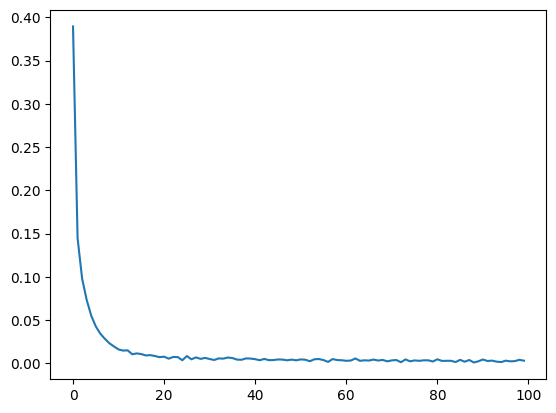

In [ ]:
# Loss curve, averaged per epoch over all batches.
plt.plot(losses);

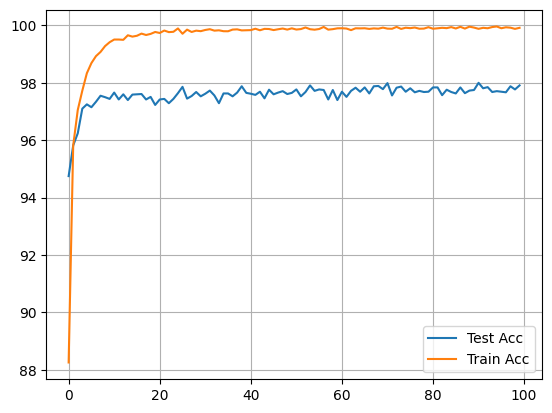

In [ ]:
# The plot that matters. Train and test accuracy rising together = still
# learning. Train climbing while test flattens or falls = overfitting, which
# is what the Regularization/ section is about.
# .cpu() is needed because matplotlib cannot read CUDA tensors.
test_acc = [i.cpu() for i in test_acc]

plt.plot(test_acc,label="Test Acc")
plt.plot(train_acc, label="Train Acc")
plt.grid()
plt.legend();

In [ ]:
# The generalisation gap in one number: train accuracy minus test accuracy.
test_acc[-1], train_acc[-1]

(tensor(97.9100), np.float32(99.916664))

In [ ]:
# Model outputs are log-probabilities, so exp() converts them back to
# probabilities that sum to 1.
X,Y = next(iter(test_loader))

preds = classifier(X)
a = torch.exp(preds)

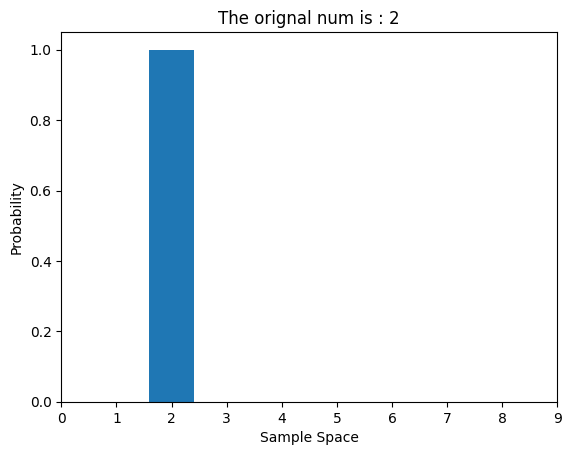

In [ ]:
# The model's confidence over all 10 digits for one test image. A tall single
# bar means a confident prediction; several similar bars mean the model is
# genuinely unsure (usually 4/9 or 3/5, the digits that look alike).
plt.bar(range(10),a[1].detach().cpu());
plt.xlim([0,9])
plt.title(f'The orignal num is : {Y[1].item()}')
plt.xlabel("Sample Space")
plt.ylabel("Probability");

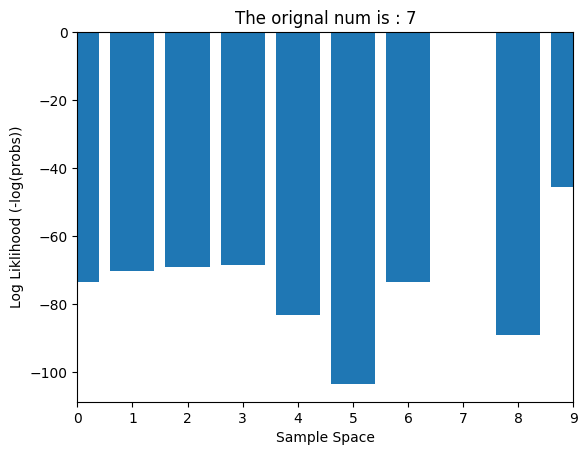

In [ ]:
# The same thing before exp(): raw log-probabilities, all <= 0, with the
# predicted class closest to 0 (since log(1) = 0).
# Note the sign: this is log(p). Negating it gives the negative log-likelihood,
# which is what NLLLoss minimises.
plt.bar(range(10),preds[0].detach().cpu());
plt.xlim([0,9])
plt.title(f'The orignal num is : {Y[0].item()}')
plt.xlabel("Sample Space")
plt.ylabel("Log probability, log(p)");

# THis makes sense as ln(1) is zero